Загружаем синтетический датасет...
Размер датасета: (44220, 16)
Колонки: ['user_id', 'cycle_id', 'day_in_cycle', 'phase', 'cycle_len', 'ovulation_day', 'steps', 'calories', 'heart_rate', 'rmssd', 'sleep_hours', 'stress_score_cycle', 'energy_level', 'mood_score', 'concentration_score', 'pain_level']
Пропуски:
user_id                   0
cycle_id                  0
day_in_cycle              0
phase                     0
cycle_len                 0
ovulation_day             0
steps                  2208
calories               2208
heart_rate             2208
rmssd                  2208
sleep_hours            2208
stress_score_cycle     2208
energy_level           2208
mood_score             2208
concentration_score    2208
pain_level             2208
dtype: int64

EDA

Распределение фаз цикла:
phase
luteal        20082
follicular    14682
menstrual      7944
ovulatory      1512
Name: count, dtype: int64

Описательная статистика:
              steps      calories    heart_rate         rmss

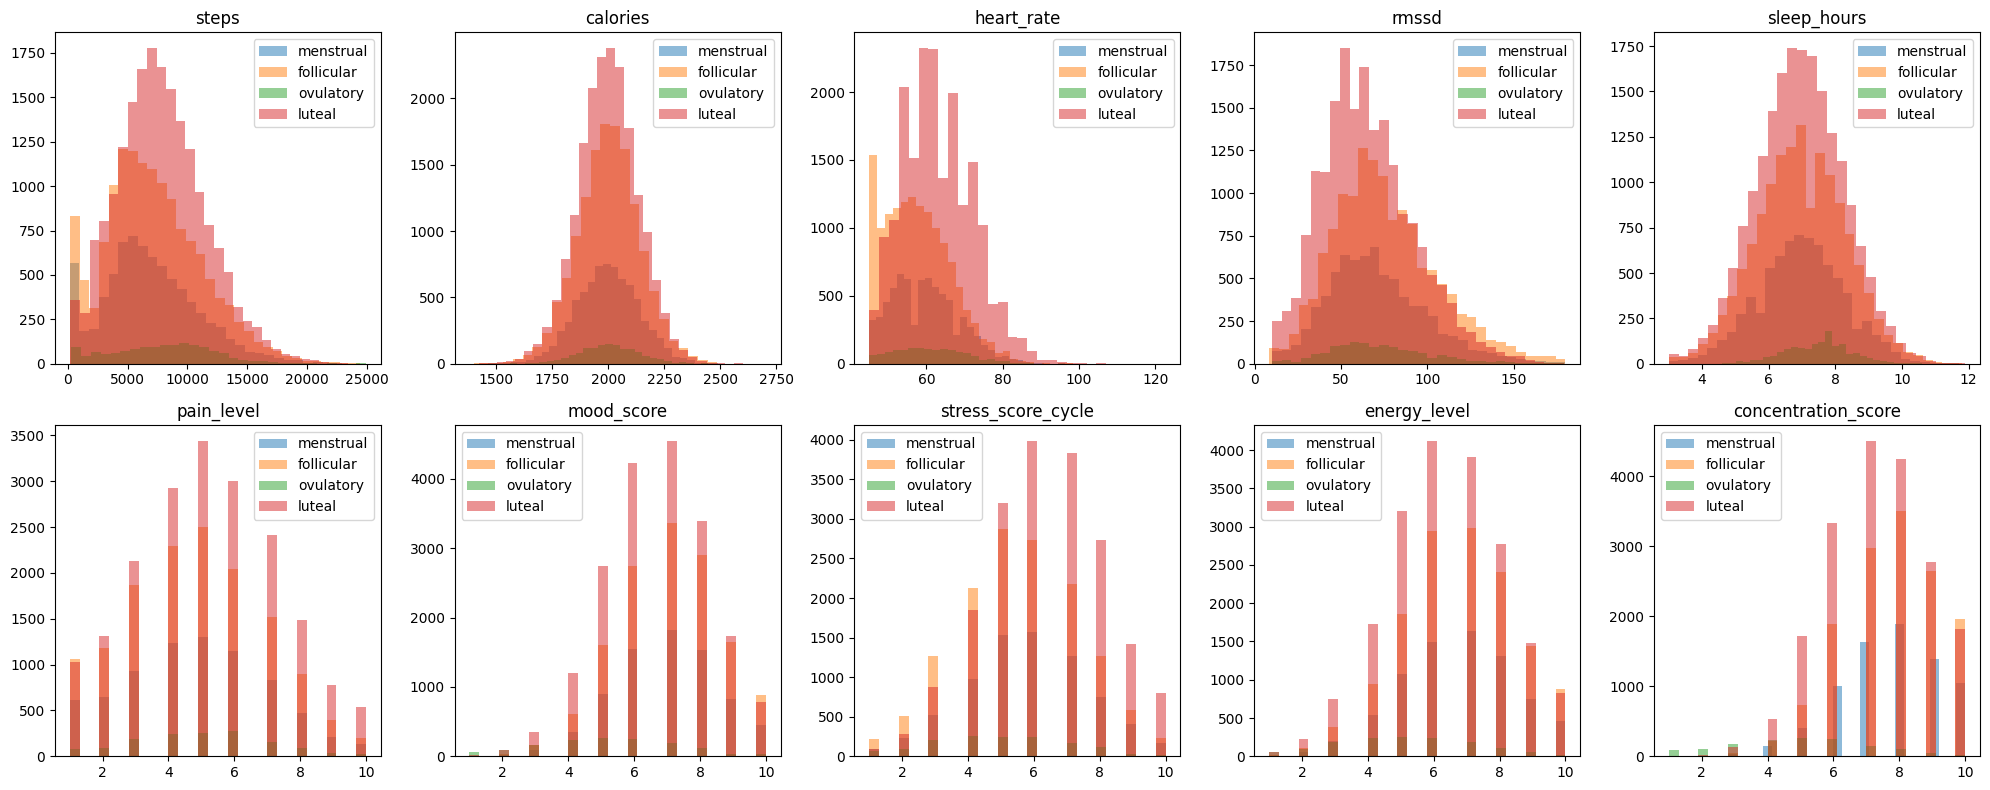

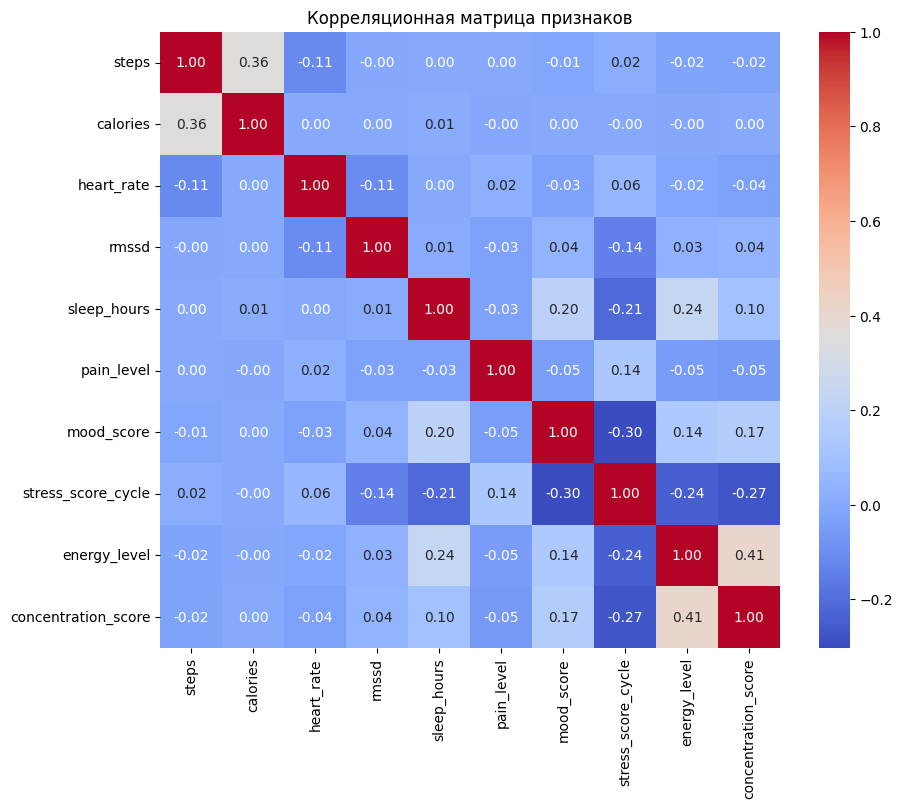

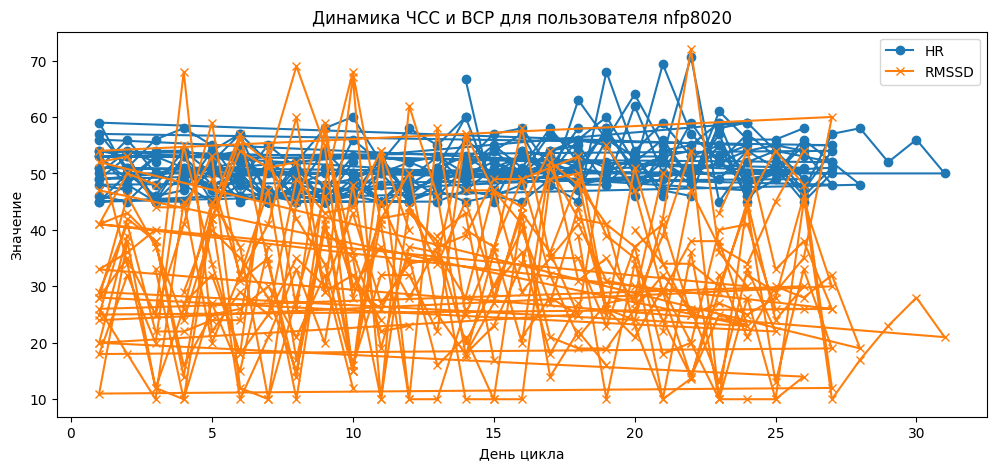


Подготовка данных
Соответствие фаз и кодов:
  follicular -> 0
  luteal -> 1
  menstrual -> 2
  ovulatory -> 3
Строк до удаления пропусков: 44220
Строк после удаления пропусков: 42012
Размер обучающей выборки: (32597, 10)
Размер тестовой выборки: (9415, 10)
Уникальных пользователей в train: 125

Логистическая регрессия
Accuracy: 0.5582580987785448

Classification Report:
              precision    recall  f1-score   support

  follicular       0.51      0.52      0.51      3061
      luteal       0.58      0.80      0.67      4380
   menstrual       0.00      0.00      0.00      1658
   ovulatory       0.66      0.49      0.56       316

    accuracy                           0.56      9415
   macro avg       0.44      0.45      0.44      9415
weighted avg       0.46      0.56      0.50      9415



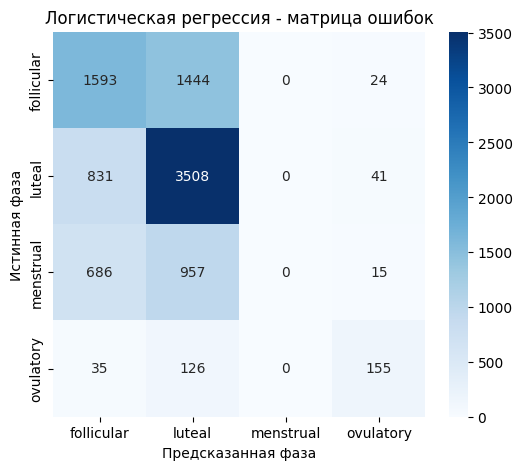


Случайный лес
Accuracy: 0.5389272437599575

Classification Report:
              precision    recall  f1-score   support

  follicular       0.50      0.45      0.47      3061
      luteal       0.56      0.81      0.66      4380
   menstrual       0.23      0.01      0.03      1658
   ovulatory       0.73      0.37      0.49       316

    accuracy                           0.54      9415
   macro avg       0.50      0.41      0.41      9415
weighted avg       0.49      0.54      0.48      9415



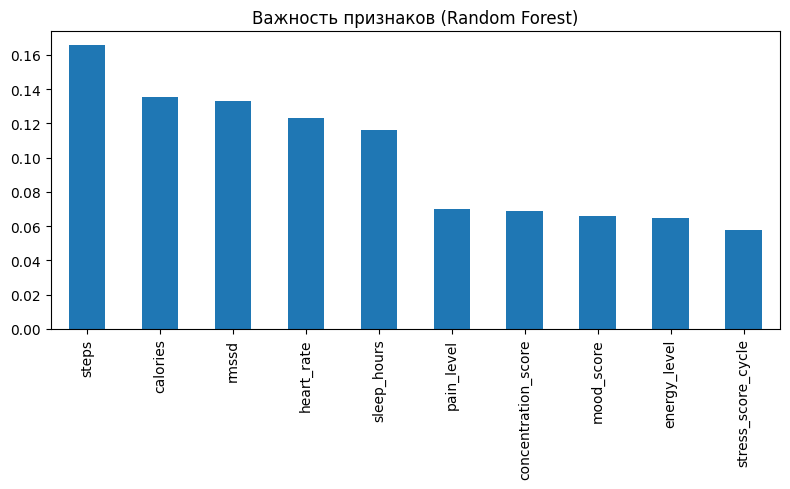

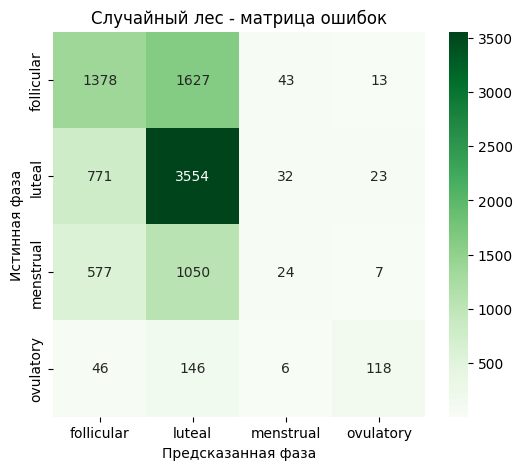


LSTM с group split и class weighting
Всего последовательностей: 33018
Обучающих последовательностей: (25619, 7, 10)
Тестовых последовательностей: (7399, 7, 10)
Уникальных пользователей в train: 125
Уникальных пользователей в test: 32
Веса классов для LSTM:
  follicular: 0.669
  luteal: 0.436
  menstrual: 27.968
  ovulatory: 5.729
Epoch 1/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4534 - loss: 1.2457 - val_accuracy: 0.4305 - val_loss: 1.1125
Epoch 2/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5313 - loss: 0.9813 - val_accuracy: 0.5176 - val_loss: 1.0086
Epoch 3/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5425 - loss: 0.8954 - val_accuracy: 0.5320 - val_loss: 0.9551
Epoch 4/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5753 - loss: 0.8627 - val_accuracy: 0.6056 - val_loss: 0.9162
Epoch 5/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5871 - loss: 0.8328 - val_accuracy: 0.5025 - val_loss: 1.0295
Epoch 6/30
641/641 ━━

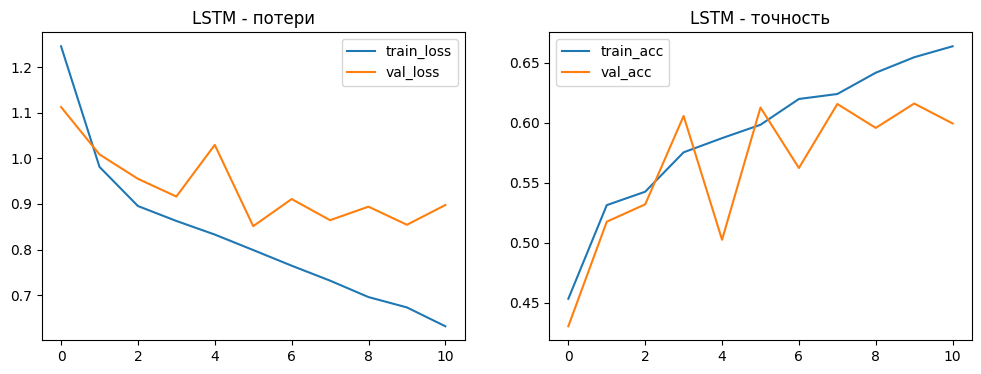

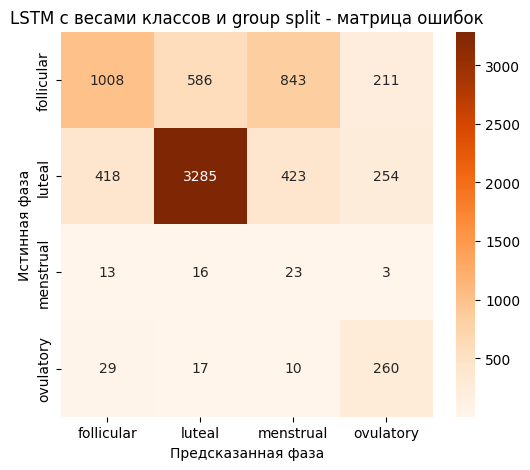


Сравнение моделей


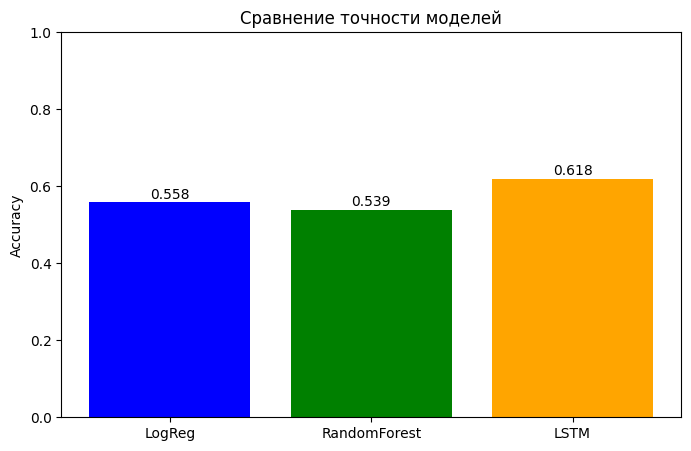

Скрипт завершён. Все графики сохранены в текущую директорию.


In [7]:
# =============================================================================
# 1. Импорт библиотек и настройка окружения
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Для LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Для воспроизводимости
np.random.seed(42)

# =============================================================================
# 2. Загрузка данных
# =============================================================================
print("Загружаем синтетический датасет...")
df = pd.read_csv('synthetic_menstrual_physiology_with_subjective.csv')
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Пропуски:\n{df.isnull().sum()}")

# =============================================================================
# 3. Исследовательский анализ данных (EDA)
# =============================================================================
print("\n" + "="*50)
print("EDA")
print("="*50)

# Распределение целевой переменной
print("\nРаспределение фаз цикла:")
print(df['phase'].value_counts())

# Описательная статистика по числовым признакам
num_cols = ['steps', 'calories', 'heart_rate', 'rmssd', 'sleep_hours',
            'pain_level', 'mood_score', 'stress_score_cycle',
            'energy_level', 'concentration_score']
print("\nОписательная статистика:")
print(df[num_cols].describe())

# Визуализация распределений по фазам
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for phase in df['phase'].unique():
        subset = df[df['phase'] == phase][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.5, label=phase)
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.savefig('feature_distributions_by_phase.png')
plt.show()

# Корреляционная матрица
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.savefig('correlation_matrix.png')
plt.show()

# Динамика признаков для одного пользователя
sample_user = df['user_id'].iloc[0]  # первый пользователь
user_data = df[df['user_id'] == sample_user].sort_values(['cycle_id', 'day_in_cycle'])
plt.figure(figsize=(12,5))
plt.plot(user_data['day_in_cycle'], user_data['heart_rate'], label='HR', marker='o')
plt.plot(user_data['day_in_cycle'], user_data['rmssd'], label='RMSSD', marker='x')
plt.xlabel('День цикла')
plt.ylabel('Значение')
plt.title(f'Динамика ЧСС и ВСР для пользователя {sample_user}')
plt.legend()
plt.savefig('sample_user_dynamics.png')
plt.show()

# =============================================================================
# 4. Подготовка данных для моделирования
# =============================================================================
print("\n" + "="*50)
print("Подготовка данных")
print("="*50)

# Кодирование целевой переменной
le = LabelEncoder()
df['phase_encoded'] = le.fit_transform(df['phase'])
# Сохраним соответствие классов
print("Соответствие фаз и кодов:")
for i, phase in enumerate(le.classes_):
    print(f"  {phase} -> {i}")

# Выделение признаков и целевой переменной
feature_cols = ['steps', 'calories', 'heart_rate', 'rmssd', 'sleep_hours',
                'pain_level', 'mood_score', 'stress_score_cycle',
                'energy_level', 'concentration_score']
target_col = 'phase_encoded'

# Удаляем строки с пропусками для обучения 
print(f"Строк до удаления пропусков: {len(df)}")
df_clean = df.dropna(subset=feature_cols + [target_col]).copy()
print(f"Строк после удаления пропусков: {len(df_clean)}")

X = df_clean[feature_cols]
y = df_clean[target_col]
groups = df_clean['user_id']  # для группового разделения

# Разделение на train/test с учётом пользователей
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Уникальных пользователей в train: {groups_train.nunique()}")

# Масштабирование признаков (для моделей, которым это нужно)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================================================
# 5. Модель 1: Логистическая регрессия
# =============================================================================
print("\n" + "="*50)
print("Логистическая регрессия")
print("="*50)

lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Матрица ошибок
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Логистическая регрессия - матрица ошибок')
plt.ylabel('Истинная фаза')
plt.xlabel('Предсказанная фаза')
plt.savefig('cm_logreg.png')
plt.show()

# =============================================================================
# 6. Модель 2: Случайный лес
# =============================================================================
print("\n" + "="*50)
print("Случайный лес")
print("="*50)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # масштабирование не требуется
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Важность признаков
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,5))
feat_imp.plot(kind='bar')
plt.title('Важность признаков (Random Forest)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

# Матрица ошибок
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Случайный лес - матрица ошибок')
plt.ylabel('Истинная фаза')
plt.xlabel('Предсказанная фаза')
plt.savefig('cm_rf.png')
plt.show()

# =============================================================================
# 7. Модель 3: LSTM с групповым разделением и весами классов
# =============================================================================
print("\n" + "="*50)
print("LSTM с group split и class weighting")
print("="*50)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupShuffleSplit

# Функция для создания последовательностей
def create_sequences(df, user_col='user_id', cycle_col='cycle_id',
                      feature_cols=None, target_col='phase_encoded', seq_len=7):
    sequences = []
    targets = []
    for (user, cycle), group in df.groupby([user_col, cycle_col]):
        group = group.sort_values('day_in_cycle')
        if len(group) < seq_len:
            continue
        for i in range(len(group) - seq_len + 1):
            seq = group.iloc[i:i+seq_len][feature_cols].values
            target = group.iloc[i+seq_len-1][target_col]
            sequences.append(seq)
            targets.append(target)
    return np.array(sequences), np.array(targets)

# Создаём последовательности
seq_len = 7
X_seq_full, y_seq_full = create_sequences(df_clean,
                                           feature_cols=feature_cols,
                                           target_col=target_col,
                                           seq_len=seq_len)
print(f"Всего последовательностей: {len(X_seq_full)}")

# Создаём список идентификаторов пользователей для каждой последовательности
user_ids_for_seq = []
for (user, cycle), group in df_clean.groupby(['user_id', 'cycle_id']):
    group = group.sort_values('day_in_cycle')
    if len(group) < seq_len:
        continue
    for i in range(len(group) - seq_len + 1):
        user_ids_for_seq.append(user)
user_ids_for_seq = np.array(user_ids_for_seq)

# Групповое разделение
gss_seq = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_seq, test_idx_seq = next(gss_seq.split(X_seq_full, y_seq_full, groups=user_ids_for_seq))

X_train_seq = X_seq_full[train_idx_seq]
X_test_seq = X_seq_full[test_idx_seq]
y_train_seq = y_seq_full[train_idx_seq]
y_test_seq = y_seq_full[test_idx_seq]

print(f"Обучающих последовательностей: {X_train_seq.shape}")
print(f"Тестовых последовательностей: {X_test_seq.shape}")
print(f"Уникальных пользователей в train: {np.unique(user_ids_for_seq[train_idx_seq]).size}")
print(f"Уникальных пользователей в test: {np.unique(user_ids_for_seq[test_idx_seq]).size}")

# Масштабирование признаков
original_shape = X_train_seq.shape
X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
scaler_seq = StandardScaler().fit(X_train_flat)
X_train_seq_scaled = scaler_seq.transform(X_train_flat).reshape(original_shape)
X_test_seq_scaled = scaler_seq.transform(X_test_seq.reshape(-1, X_test_seq.shape[-1])).reshape(X_test_seq.shape)

# Вычисление весов классов
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_seq), y=y_train_seq)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Веса классов для LSTM:")
for cls, weight in class_weight_dict.items():
    phase_name = le.inverse_transform([cls])[0]
    print(f"  {phase_name}: {weight:.3f}")

# Модель LSTM
model_lstm = Sequential([
    LSTM(64, input_shape=(seq_len, len(feature_cols)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

model_lstm.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Обучение с весами классов
history = model_lstm.fit(
    X_train_seq_scaled, y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# Оценка на тесте
loss, acc = model_lstm.evaluate(X_test_seq_scaled, y_test_seq, verbose=0)
print(f"LSTM Test Accuracy: {acc:.4f}")

# Предсказания
y_pred_lstm = model_lstm.predict(X_test_seq_scaled)
y_pred_lstm_classes = np.argmax(y_pred_lstm, axis=1)

print("\nClassification Report (LSTM):")
print(classification_report(y_test_seq, y_pred_lstm_classes, target_names=le.classes_))

# График обучения
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('LSTM - потери')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('LSTM - точность')
plt.legend()
plt.savefig('lstm_training_weighted_group.png')
plt.show()

# Матрица ошибок LSTM
cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('LSTM с весами классов и group split - матрица ошибок')
plt.ylabel('Истинная фаза')
plt.xlabel('Предсказанная фаза')
plt.savefig('cm_lstm_weighted_group.png')
plt.show()

# =============================================================================
# 8. Сравнение моделей
# =============================================================================
print("\n" + "="*50)
print("Сравнение моделей")
print("="*50)

models = ['LogReg', 'RandomForest', 'LSTM']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    acc  # уже посчитано
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.ylabel('Accuracy')
plt.title('Сравнение точности моделей')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.ylim(0, 1.0)
plt.savefig('model_comparison.png')
plt.show()

print("Скрипт завершён. Все графики сохранены в текущую директорию.")


LSTM для предсказания субъективных показателей (групповое разбиение)

Обучение для stress_score_cycle
Всего последовательностей: 33018
Обучающих: (25619, 7, 10), тестовых: (7399, 7, 10)
Epoch 1/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 3.4464 - mae: 1.1363 - val_loss: 0.0538 - val_mae: 0.1562
Epoch 2/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.3789 - mae: 0.4781 - val_loss: 0.0337 - val_mae: 0.1183
Epoch 3/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.3370 - mae: 0.4483 - val_loss: 0.0440 - val_mae: 0.1665
Epoch 4/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.2867 - mae: 0.4128 - val_loss: 0.0175 - val_mae: 0.0858
Epoch 5/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2412 - mae: 0.3752 - val_loss: 0.0273 - val_mae: 0.1175
Epoch 6/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.1957 - mae: 0.3353 - val_loss: 0.0183 - val_mae: 0.0871
Epoch 7/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.1602 - mae: 0.2999 - val_loss: 0.01

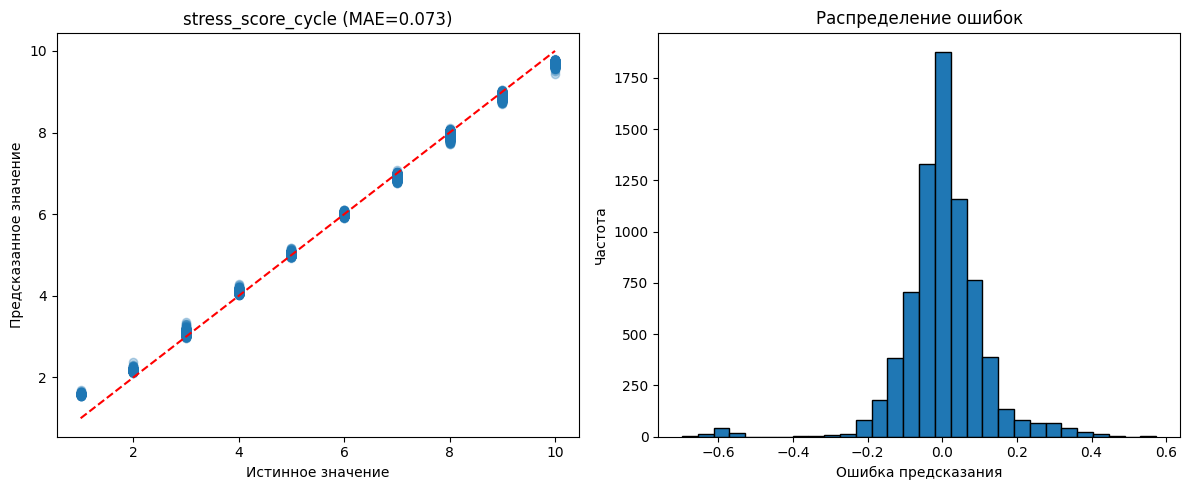

Модель сохранена как lstm_stress_score_cycle_regression_group.keras


Обучение для energy_level
Всего последовательностей: 33018
Обучающих: (25619, 7, 10), тестовых: (7399, 7, 10)
Epoch 1/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 3.9156 - mae: 1.2627 - val_loss: 0.0694 - val_mae: 0.1954
Epoch 2/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.4734 - mae: 0.5347 - val_loss: 0.0441 - val_mae: 0.1424
Epoch 3/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.3996 - mae: 0.4894 - val_loss: 0.0693 - val_mae: 0.2241
Epoch 4/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3481 - mae: 0.4565 - val_loss: 0.0314 - val_mae: 0.1108
Epoch 5/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2861 - mae: 0.4124 - val_loss: 0.0165 - val_mae: 0.0810
Epoch 6/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.2288 - mae: 0.3676 - val_loss: 0.0331 - val_mae: 0.1476
Epoch 7/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.1824 - mae: 0.3239 - val_loss: 0.0113 - va

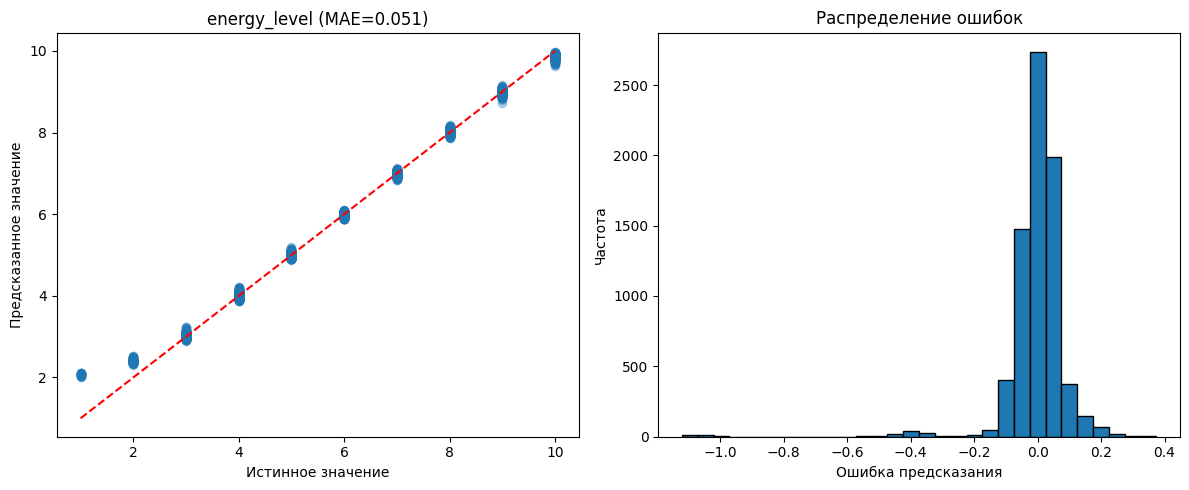

Модель сохранена как lstm_energy_level_regression_group.keras


Обучение для mood_score
Всего последовательностей: 33018
Обучающих: (25619, 7, 10), тестовых: (7399, 7, 10)
Epoch 1/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 6.5573 - mae: 1.8655 - val_loss: 2.6580 - val_mae: 1.3120
Epoch 2/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.9155 - mae: 0.7027 - val_loss: 0.0499 - val_mae: 0.1296
Epoch 3/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.4241 - mae: 0.5074 - val_loss: 0.0319 - val_mae: 0.1206
Epoch 4/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3767 - mae: 0.4784 - val_loss: 0.0420 - val_mae: 0.1652
Epoch 5/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.3407 - mae: 0.4525 - val_loss: 0.0239 - val_mae: 0.1107
Epoch 6/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2973 - mae: 0.4239 - val_loss: 0.0171 - val_mae: 0.0916
Epoch 7/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.2645 - mae: 0.3973 - val_loss: 0.0238 - val_mae: 0

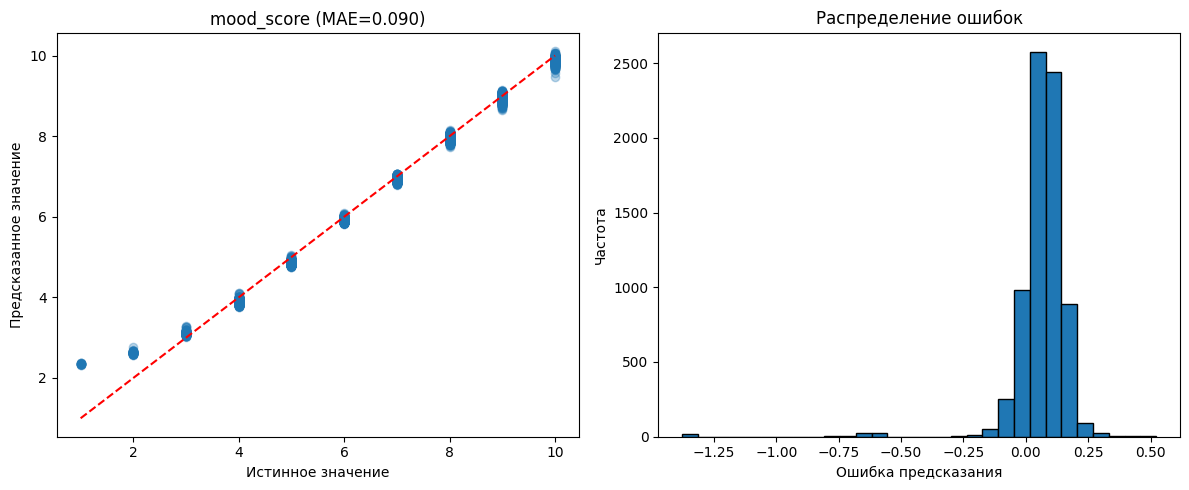

Модель сохранена как lstm_mood_score_regression_group.keras


Обучение для concentration_score
Всего последовательностей: 33018
Обучающих: (25619, 7, 10), тестовых: (7399, 7, 10)
Epoch 1/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5.5896 - mae: 1.5170 - val_loss: 0.0596 - val_mae: 0.1553
Epoch 2/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.5314 - mae: 0.5712 - val_loss: 0.0618 - val_mae: 0.1894
Epoch 3/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.4737 - mae: 0.5396 - val_loss: 0.0281 - val_mae: 0.1154
Epoch 4/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.4271 - mae: 0.5095 - val_loss: 0.0288 - val_mae: 0.1015
Epoch 5/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.3829 - mae: 0.4834 - val_loss: 0.0258 - val_mae: 0.1093
Epoch 6/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3286 - mae: 0.4436 - val_loss: 0.0486 - val_mae: 0.1838
Epoch 7/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.2734 - mae: 0.4024 - val_loss: 0.0345 - val

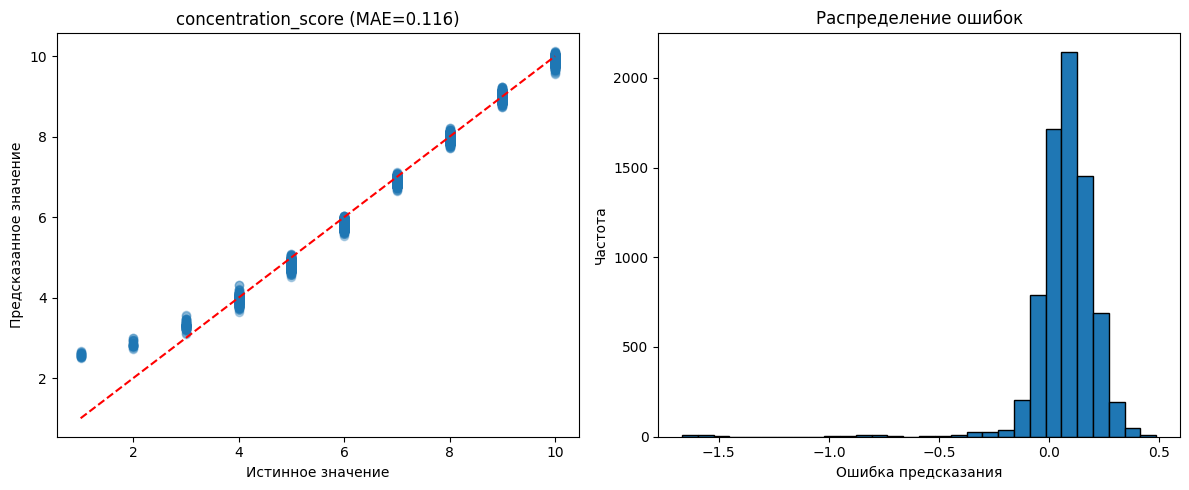

Модель сохранена как lstm_concentration_score_regression_group.keras


Обучение для pain_level
Всего последовательностей: 33018
Обучающих: (25619, 7, 10), тестовых: (7399, 7, 10)
Epoch 1/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 3.2268 - mae: 1.1544 - val_loss: 0.0729 - val_mae: 0.2013
Epoch 2/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.3365 - mae: 0.4467 - val_loss: 0.0615 - val_mae: 0.1799
Epoch 3/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.2789 - mae: 0.4041 - val_loss: 0.0509 - val_mae: 0.1986
Epoch 4/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2319 - mae: 0.3664 - val_loss: 0.0723 - val_mae: 0.2276
Epoch 5/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.1994 - mae: 0.3369 - val_loss: 0.0747 - val_mae: 0.2257
Epoch 6/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.1643 - mae: 0.3026 - val_loss: 0.0173 - val_mae: 0.1090
Epoch 7/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.1419 - mae: 0.2806 - val_loss: 0.1003 - val

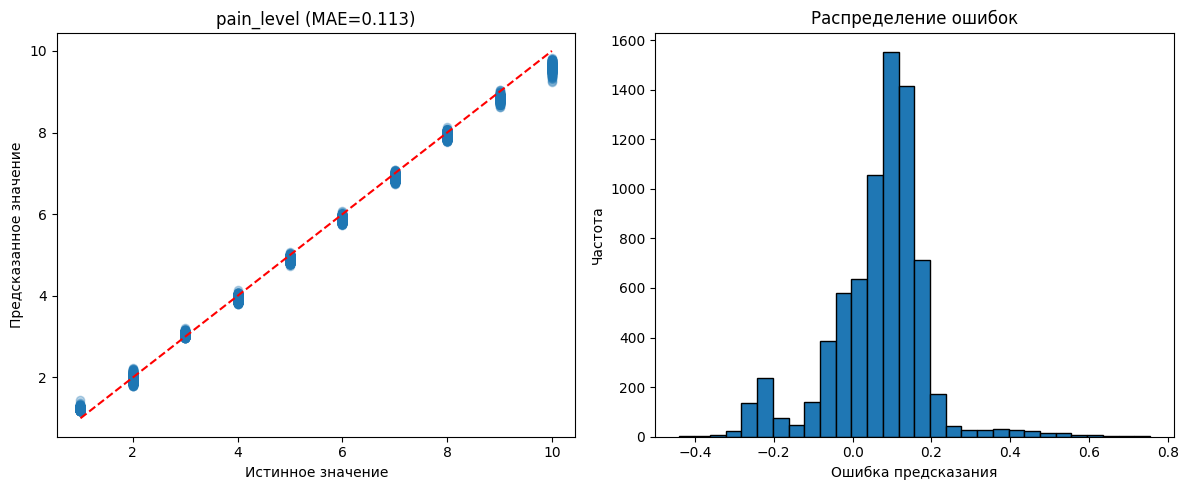

Модель сохранена как lstm_pain_level_regression_group.keras


Сводка результатов
stress_score_cycle: MAE = 0.0732
energy_level: MAE = 0.0514
mood_score: MAE = 0.0900
concentration_score: MAE = 0.1158
pain_level: MAE = 0.1128


In [8]:
# =============================================================================
# 9. LSTM для предсказания субъективных показателей (регрессия) с групповым разделением
# =============================================================================
print("\n" + "="*50)
print("LSTM для предсказания субъективных показателей (групповое разбиение)")
print("="*50)

# Убедимся, что функция create_sequences определена
def create_sequences(df, user_col='user_id', cycle_col='cycle_id',
                      feature_cols=None, target_col='phase_encoded', seq_len=7):
    sequences = []
    targets = []
    for (user, cycle), group in df.groupby([user_col, cycle_col]):
        group = group.sort_values('day_in_cycle')
        if len(group) < seq_len:
            continue
        for i in range(len(group) - seq_len + 1):
            seq = group.iloc[i:i+seq_len][feature_cols].values
            target = group.iloc[i+seq_len-1][target_col]
            sequences.append(seq)
            targets.append(target)
    return np.array(sequences), np.array(targets)

# Список целевых переменных
targets = ['stress_score_cycle', 'energy_level', 'mood_score', 'concentration_score', 'pain_level']
results = {}

# Параметры
seq_len = 7
feature_cols = ['steps', 'calories', 'heart_rate', 'rmssd', 'sleep_hours',
                'pain_level', 'mood_score', 'stress_score_cycle',
                'energy_level', 'concentration_score']

# Обучение для каждой целевой переменной
for target in targets:
    print(f"\n{'='*50}")
    print(f"Обучение для {target}")
    print('='*50)
    
    # Создаём последовательности
    X_seq_full, y_seq_full = create_sequences(df_clean,
                                              feature_cols=feature_cols,
                                              target_col=target,
                                              seq_len=seq_len)
    print(f"Всего последовательностей: {len(X_seq_full)}")
    
    # Создаём список идентификаторов пользователей для каждой последовательности
    user_ids_for_seq = []
    for (user, cycle), group in df_clean.groupby(['user_id', 'cycle_id']):
        group = group.sort_values('day_in_cycle')
        if len(group) < seq_len:
            continue
        for i in range(len(group) - seq_len + 1):
            user_ids_for_seq.append(user)
    user_ids_for_seq = np.array(user_ids_for_seq)
    
    # Групповое разделение
    gss_seq = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx_seq, test_idx_seq = next(gss_seq.split(X_seq_full, y_seq_full, groups=user_ids_for_seq))
    
    X_train_seq = X_seq_full[train_idx_seq]
    X_test_seq = X_seq_full[test_idx_seq]
    y_train_seq = y_seq_full[train_idx_seq]
    y_test_seq = y_seq_full[test_idx_seq]
    
    print(f"Обучающих: {X_train_seq.shape}, тестовых: {X_test_seq.shape}")
    
    # Масштабирование
    original_shape = X_train_seq.shape
    X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
    scaler_seq = StandardScaler().fit(X_train_flat)
    X_train_seq_scaled = scaler_seq.transform(X_train_flat).reshape(original_shape)
    X_test_seq_scaled = scaler_seq.transform(X_test_seq.reshape(-1, X_test_seq.shape[-1])).reshape(X_test_seq.shape)
    
    # Модель
    model = Sequential([
        LSTM(64, input_shape=(seq_len, len(feature_cols)), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    # Обучение
    history = model.fit(
        X_train_seq_scaled, y_train_seq,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Оценка
    loss, mae = model.evaluate(X_test_seq_scaled, y_test_seq, verbose=0)
    print(f"Test MAE: {mae:.4f}")
    results[target] = mae
    
    # Предсказания и визуализация
    y_pred = model.predict(X_test_seq_scaled).flatten()
    
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.scatter(y_test_seq, y_pred, alpha=0.3)
    plt.plot([min(y_test_seq), max(y_test_seq)], [min(y_test_seq), max(y_test_seq)], 'r--')
    plt.xlabel('Истинное значение')
    plt.ylabel('Предсказанное значение')
    plt.title(f'{target} (MAE={mae:.3f})')
    
    plt.subplot(1,2,2)
    residuals = y_test_seq - y_pred
    plt.hist(residuals, bins=30, edgecolor='black')
    plt.xlabel('Ошибка предсказания')
    plt.ylabel('Частота')
    plt.title('Распределение ошибок')
    plt.tight_layout()
    plt.savefig(f'lstm_{target}_regression_group.png')
    plt.show()
    
    # Сохранение модели в формате .keras
    model.save(f'lstm_{target}_regression_group.keras')
    print(f"Модель сохранена как lstm_{target}_regression_group.keras\n")

# Вывод сводной таблицы
print("\n" + "="*50)
print("Сводка результатов")
print("="*50)
for target, mae in results.items():
    print(f"{target}: MAE = {mae:.4f}")